# Familiarize myself with the tasks

Making viz always helps :D

In [1]:
import matplotlib.pyplot as plt
import numpy as np

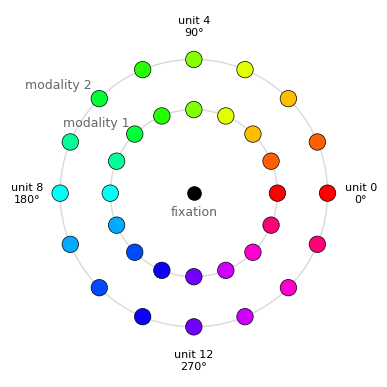

In [2]:
N_RING = 16
RADII = {"modality 1": 1.0, "modality 2": 1.6}

theta = np.linspace(0, 2 * np.pi, N_RING, endpoint=False)
colors = plt.cm.hsv(theta / (2 * np.pi))

fig, ax = plt.subplots(figsize=(4, 4))

for label, r in RADII.items():
    phi = np.linspace(0, 2 * np.pi, 200)
    ax.plot(r * np.cos(phi), r * np.sin(phi), color="0.85", lw=1, zorder=0)
    ax.scatter(r * np.cos(theta), r * np.sin(theta), c=colors, s=140,
               edgecolors="k", linewidths=0.5, zorder=2)
    ang = np.deg2rad(135)
    ax.text(r * np.cos(ang) * 1.08, r * np.sin(ang) * 1.08, label,
            ha="right", va="bottom", fontsize=9, color="0.4")

ax.scatter([0], [0], c="k", s=90, zorder=2)
ax.text(0, -0.15, "fixation", ha="center", va="top", fontsize=9, color="0.4")

for k in (0, 4, 8, 12):
    x, y = 2.0 * np.cos(theta[k]), 2.0 * np.sin(theta[k])
    ax.text(x, y, f"unit {k}\n{np.degrees(theta[k]):.0f}°", ha="center", va="center", fontsize=8)

ax.set_aspect("equal")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.axis("off")
#ax.set_title("Mod-Cog Setup")
plt.tight_layout()
#plt.savefig("modcog.png",  dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [8]:
import fastplotlib as fpl
import Mod_Cog.mod_cog_tasks as mct
from ipywidgets import IntSlider, VBox, Layout
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

Image(value=b'version https://git-lfs.github.com/spec/...', height='55', width='300')

Valid,Device,Type,Backend,Driver
✅,Intel(R) Arc(tm) Graphics (MTL),IntegratedGPU,Vulkan,Mesa 26.0.7
✅ (default),NVIDIA GeForce RTX 4060 Laptop GPU,DiscreteGPU,Vulkan,595.71.05
❗ limited,"llvmpipe (LLVM 22.1.5, 256 bits)",CPU,Vulkan,Mesa 26.0.7 (LLVM 22.1.5)
❌,NVIDIA GeForce RTX 4060 Laptop GPU/PCIe/SSE2,Unknown,OpenGL,3.3.0 NVIDIA 595.71.05


## Model

In [9]:
class LeakyRNN(nn.Module):
    def __init__(self, n_in, n_hidden, n_out, alpha, sigma_rec, activation):
        super().__init__()
        self.alpha = alpha
        self.noise_scale = math.sqrt(2 / alpha) * sigma_rec
        self.act = ACTIVATIONS[activation]
        self.n_hidden = n_hidden
        self.w_in = nn.Linear(n_in, n_hidden)
        self.w_rec = nn.Linear(n_hidden, n_hidden, bias=False)
        self.readout = nn.Linear(n_hidden, n_out)
 
    def forward(self, x):
        b, t, _ = x.shape
        h = x.new_zeros(b, self.n_hidden)
        hs = []
        for i in range(t):
            pre = self.w_in(x[:, i]) + self.w_rec(h)
            if self.training and self.noise_scale > 0:
                pre = pre + self.noise_scale * torch.randn_like(pre)
            h = (1 - self.alpha) * h + self.alpha * self.act(pre)
            hs.append(h)
        hidden = torch.stack(hs, dim=1)
        return self.readout(hidden), hidden

## Constants

In [11]:
BANK_PATH = "modcog_bank.pt"
CKPT_PATH = "modcog_rnn.pt"
DEVICE = "cuda"
TASKS = ["dlygo", "ctxdm1", "dms", "goseqr"]
TRIAL_PICK = 0  # which trial of each task to show (index within that task's trials)
 
N_RING = 16
FIX_INDEX = 0
SLICES = {"mod1": slice(1, 1 + N_RING), "mod2": slice(1 + N_RING, 1 + 2 * N_RING)}
RADII = {"mod1": 1.0, "mod2": 1.6}
OUT_RADIUS = 1.0
TARGET_RADIUS = 1.35
 
OFF_COLOR = np.array([0.25, 0.25, 0.25, 1.0], dtype=np.float32)
ON_COLORS = {
    "fix": np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32),
    "mod1": np.array([0.2, 0.7, 1.0, 1.0], dtype=np.float32),
    "mod2": np.array([1.0, 0.5, 0.1, 1.0], dtype=np.float32),
    "out": np.array([0.3, 1.0, 0.4, 1.0], dtype=np.float32),
}
TARGET_COLOR = np.array([1.0, 1.0, 1.0, 0.9], dtype=np.float32)
HIDDEN_COLOR = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)
GUIDE_COLOR = (0.4, 0.4, 0.4, 0.5)
VECTOR_COLOR = (1.0, 1.0, 0.3, 1.0)
BASE_SIZE = 8.0
MAX_SIZE = 24.0
INPUT_FLOOR = 0.3  # inputs are noisy; only show activity above this
ACTIVATIONS = {"relu": F.relu, "tanh": torch.tanh, "softplus": F.softplus}

## Helper funcs

In [12]:
def ring_positions(radius, n=N_RING):
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return np.column_stack([radius * np.cos(theta), radius * np.sin(theta), np.zeros(n)]).astype(np.float32)
 
 
def guide_circle(radius, n=128):
    phi = np.linspace(0, 2 * np.pi, n + 1)
    return np.column_stack([radius * np.cos(phi), radius * np.sin(phi), np.zeros(n + 1)]).astype(np.float32)
 
 
def activation_style(values, on_color, floor=0.0, vmax=1.0):
    a = np.clip((np.asarray(values) - floor) / (vmax - floor), 0.0, 1.0)
    a = a[:, None].astype(np.float32)
    colors = (1 - a) * OFF_COLOR + a * on_color
    sizes = BASE_SIZE + (MAX_SIZE - BASE_SIZE) * a[:, 0]
    return colors, sizes

In [13]:
bank = torch.load(BANK_PATH, map_location=DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
task_names = bank["task_names"]
n_tasks = len(task_names)
 
model = LeakyRNN(**ckpt["config"]).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
 
theta_ring = np.linspace(0, 2 * np.pi, N_RING, endpoint=False)
ring_xy = np.column_stack([np.cos(theta_ring), np.sin(theta_ring)])
 
trials = {}
with torch.no_grad():
    for name in TASKS:
        tid = task_names.index(name)
        rows = torch.nonzero(bank["task_id"] == tid).flatten()
        idx = rows[TRIAL_PICK]
        ob = bank["obs"][idx]                                   # (T, 33)
        rule = F.one_hot(bank["task_id"][idx], n_tasks).float()
        x = torch.cat([ob, rule[None].expand(ob.shape[0], -1)], dim=-1)[None]
        logits, _ = model(x)
        probs = logits.softmax(-1)[0]                           # (T, 17)
        trials[name] = {
            "ob": ob.cpu().numpy(),
            "labels": bank["labels"][idx].cpu().numpy(),
            "probs": probs.cpu().numpy(),
            "length": int(bank["lengths"][idx]),
        }
 
t_max = max(tr["length"] for tr in trials.values())

In [32]:
names = [f"{n}" for n in TASKS] + [f"{n} (model)" for n in TASKS]
figure = fpl.Figure(shape=(2, len(TASKS)), names=names, size=(360 * len(TASKS), 760))
graphics = {}
 
for col, name in enumerate(TASKS):
    tr = trials[name]
 
    top = figure[0, col]
    for mod, radius in RADII.items():
        top.add_line(guide_circle(radius), colors=GUIDE_COLOR, thickness=1.0)
        colors, sizes = activation_style(tr["ob"][0, SLICES[mod]], ON_COLORS[mod], floor=INPUT_FLOOR)
        graphics[(name, mod)] = top.add_scatter(ring_positions(radius), colors=colors, sizes=sizes)
    colors, sizes = activation_style(tr["ob"][0, [FIX_INDEX]], ON_COLORS["fix"], floor=INPUT_FLOOR)
    graphics[(name, "fix")] = top.add_scatter(np.zeros((1, 3), dtype=np.float32), colors=colors, sizes=sizes)
 
    bottom = figure[1, col]
    bottom.add_line(guide_circle(OUT_RADIUS), colors=GUIDE_COLOR, thickness=1.0)
    colors, sizes = activation_style(tr["probs"][0, 1:], ON_COLORS["out"])
    graphics[(name, "out")] = bottom.add_scatter(ring_positions(OUT_RADIUS), colors=colors, sizes=sizes)
    colors, sizes = activation_style(tr["probs"][0, [0]], ON_COLORS["fix"])
    graphics[(name, "outfix")] = bottom.add_scatter(np.zeros((1, 3), dtype=np.float32), colors=colors, sizes=sizes)
    graphics[(name, "target")] = bottom.add_scatter(
        ring_positions(TARGET_RADIUS), colors=np.tile(HIDDEN_COLOR, (N_RING, 1)), sizes=np.full(N_RING, 14.0, np.float32)
    )
    graphics[(name, "vector")] = bottom.add_line(
        np.zeros((2, 3), dtype=np.float32), colors=VECTOR_COLOR, thickness=2.0
    )

for subplot in figure:
    subplot.axes.visible = False
    subplot.auto_scale(maintain_aspect=True)
    subplot.tooltip.enabled = False
    subplot.controller.enabled = False
    subplot.toolbar = False

text_graphic = figure[0, 0].add_text(f"t = 0", font_size=15, offset=(-1, 2, 0))

In [33]:
def update_frame(t):
    """Show timestep t: inputs on top, model output distribution on the bottom."""
    for name in TASKS:
        tr = trials[name]
        i = min(t, tr["length"] - 1)
 
        for key, sl in (("mod1", SLICES["mod1"]), ("mod2", SLICES["mod2"]), ("fix", [FIX_INDEX])):
            colors, sizes = activation_style(tr["ob"][i, sl], ON_COLORS[key], floor=INPUT_FLOOR)
            graphics[(name, key)].colors[:] = colors
            graphics[(name, key)].sizes[:] = sizes
 
        p = tr["probs"][i]
        colors, sizes = activation_style(p[1:], ON_COLORS["out"])
        graphics[(name, "out")].colors[:] = colors
        graphics[(name, "out")].sizes[:] = sizes
        colors, sizes = activation_style(p[[0]], ON_COLORS["fix"])
        graphics[(name, "outfix")].colors[:] = colors
        graphics[(name, "outfix")].sizes[:] = sizes
 
        target_colors = np.tile(HIDDEN_COLOR, (N_RING, 1))
        label = tr["labels"][i]
        if label > 0:
            target_colors[label - 1] = TARGET_COLOR
        graphics[(name, "target")].colors[:] = target_colors
 
        # population vector of the predicted ring distribution
        vec = (p[1:, None] * ring_xy).sum(axis=0)
        line = np.zeros((2, 3), dtype=np.float32)
        line[1, :2] = vec
        graphics[(name, "vector")].data[:] = line

In [67]:
OUT = "/home/caitlinlewis/Desktop/goanti/"
SAVE = False

In [59]:
slider = IntSlider(value=0, min=0, max=t_max, layout=Layout(width="50%"))

def update(ev):
    t = ev["new"] 

    update_frame(t) 

    text_graphic.text = f"t = {t}"

   # figure.canvas.force_draw()

    if SAVE:
        figure.export(f"{OUT}image_{t}.png")

slider.observe(update, "value")

In [60]:
VBox([figure.show(autoscale=False), slider])

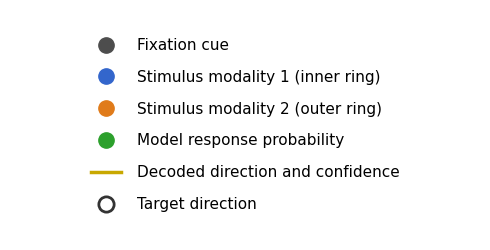

In [71]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

handles = [
    Line2D([], [], marker="o", ls="", ms=11, color="0.3", label="Fixation cue"),
    Line2D([], [], marker="o", ls="", ms=11, color="#3366cc", label="Stimulus modality 1 (inner ring)"),
    Line2D([], [], marker="o", ls="", ms=11, color="#e07b1a", label="Stimulus modality 2 (outer ring)"),
    Line2D([], [], marker="o", ls="", ms=11, color="#2ca02c", label="Model response probability"),
    Line2D([], [], color="#c8a800", lw=2.5, label="Decoded direction and confidence"),
    Line2D([], [], marker="o", ls="", ms=11, mfc="none", mec="0.2", mew=2, label="Target direction"),
]

fig, ax = plt.subplots(figsize=(5, 2.6))
ax.legend(handles=handles, loc="center", frameon=False, fontsize=11,
          handletextpad=1.0, labelspacing=1.1)
ax.axis("off")
plt.tight_layout()
#fig.savefig("modcog_legend.png", dpi=300, bbox_inches="tight")
plt.show()